# low cut event-db notebook

这个 notebook 不改你原来的分析流程。  
它单独使用 `low_cut_utils.py`，目标是：

1. 先读取并保存 event-level 数据到 pkl
2. 再从 pkl 画 low-cut true 的 histogram 阴影
3. 后续改 bins / range 时不用重新读 lh5


In [10]:
# 如果需要，可取消注释并改成你的路径
import sys
# sys.path.append(r'.')

from importlib import reload
import os
import low_cut_utils_modified as ref 
reload(ref)
from low_cut_utils_modified import *
import numpy as np
from lgdo import lh5
import numpy as np
import awkward as ak
from lgdo import lh5
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "05"
run_cal = "057"

# bg run 6 days
pnum_phy_bg = "00"
run_phy_bg = "038"
# signal run 13 days
pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7'
]



def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)

        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")
        missing_this_run = []
        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")
        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "time_ns": int(m.group(1)),
            "mw": int(m.group(2)),
            "interval": f"{m.group(1)}ns",
            "mw_label": f"mw{m.group(2)}",
            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,
            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,
            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )
    return db
run_db = build_run_db(runs, filepath)


## 先确认环境里有 `run_db` 和 `lh5`

In [5]:

if 'run_db' not in globals():
    raise RuntimeError('run_db is not defined')
if 'lh5' not in globals():
    raise RuntimeError('lh5 is not defined')
print('run_db exists:', 'run_db' in globals())
print('lh5 exists  :', 'lh5' in globals())

run_db exists: True
lh5 exists  : True


In [4]:
obj=safe_lh5_read(lh5, "ch001/hit", run_db['s100ns_mw1']['cal_pathlist'])

In [9]:
obj.view_as('pd')

,A_max_mw_o_E_Classifier,A_max_mw_o_E_Corrected,A_max_mw_o_E_Double_Sided_Cut,A_max_mw_o_E_High_Side_Cut,A_max_mw_o_E_Low_Cut,A_max_mw_o_E_Timecorr,A_max_mw_o_E_Uncorr,A_max_mw_o_E_fix_Classifier,A_max_mw_o_E_fix_Corrected,A_max_mw_o_E_fix_Double_Sided_Cut,...,is_valid_bl_slope_rms,is_valid_leading_edge,is_valid_tail,is_valid_tail_rms,is_valid_waveform,timestamp,trapEftp_cal,trapEftp_fix_cal,trapEmax_cal,trapEmax_fix_cal
0,NaN,-334.021268,False,False,False,-337.607090,-279.523224,14.644668,545.492780,False,...,True,True,True,True,True,1.707824e+09,-0.353655,0.216515,1.988491,3.158635
1,32.801372,43.114923,False,False,True,43.570544,36.074417,50.038441,60.557948,False,...,True,False,True,True,False,1.707824e+09,17.736582,12.624903,19.266447,15.496896
2,30.317943,36.122894,False,False,True,36.503939,30.223592,46.546770,55.415502,False,...,True,False,True,True,False,1.707824e+09,19.787962,12.895760,21.804843,16.708322
3,-0.293006,0.966288,True,True,True,0.974581,0.806909,-0.366898,0.962872,True,...,True,True,True,True,True,1.707824e+09,231.829786,232.620525,231.811524,232.294761
4,-0.262867,0.991218,True,True,True,0.993764,0.822791,-0.212591,0.993000,True,...,True,True,True,True,True,1.707824e+09,880.534278,878.910156,880.503732,880.468182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090056,NaN,-171.461275,False,False,False,-173.302381,-143.486442,13.593659,625.819400,False,...,True,True,True,True,True,1.707919e+09,-0.615235,0.168532,1.676781,3.615232
3090057,6.842643,107.063753,False,False,True,108.211522,89.594189,12.842137,120.589264,False,...,True,True,True,True,True,1.707919e+09,1.251734,1.111134,1.837739,2.941164
3090058,NaN,-21.915241,False,False,False,-22.151452,-18.340389,NaN,-34.588926,False,...,True,True,True,True,True,1.707919e+09,-5.003400,-3.169586,1.743139,3.518631
3090059,-2.463333,0.941827,False,True,False,0.940612,0.778784,-2.498854,0.940839,False,...,True,True,True,True,True,1.707919e+09,1296.667273,1298.091789,1296.756031,1296.575738


In [ ]:
len(obj['A_max_mw_o_E_Low_Cut'])

In [ ]:
obj2 = lh5.read("ch001/hit", run_db['s100ns_mw1']['cal_pathlist'])

In [ ]:
len(obj2['A_max_mw_o_E_Low_Cut'])

## 选一个测试 run

In [7]:
preferred_run = 's100ns_mw5'
run_db = build_run_db(runs, filepath)
if preferred_run in run_db:
    test_run = preferred_run
else:
    test_run = sorted(run_db.keys())[0]

info = run_db[test_run]
print('test_run =', test_run)
print('interval =', info['interval'])
print('mw       =', info['mw_label'])


test_run = s100ns_mw5
interval = 100ns
mw       = mw5


## 看一下字段，确认 low-cut boolean 字段名

In [8]:
ch = 'ch002'   # 改成 'ch001' 或 'ch002'

cal_fields = get_available_fields(lh5, f'{ch}/hit', info['cal_pathlist'])
# bg_fields = get_available_fields(lh5, f'{ch}/hit', info['phy_bg_pathlist'])
# signal_fields = get_available_fields(lh5, f'{ch}/hit', info['phy_signal_pathlist'])

print('CAL fields:')
print(cal_fields)
print()
# print('PHY BG fields:')
# print(bg_fields)
# print()
# print('PHY SIGNAL fields:')
# print(signal_fields)


CAL fields:
['A_max_mw_o_E_Classifier', 'A_max_mw_o_E_Corrected', 'A_max_mw_o_E_Double_Sided_Cut', 'A_max_mw_o_E_High_Side_Cut', 'A_max_mw_o_E_Low_Cut', 'A_max_mw_o_E_Timecorr', 'A_max_mw_o_E_Uncorr', 'A_max_mw_o_E_fix_Classifier', 'A_max_mw_o_E_fix_Corrected', 'A_max_mw_o_E_fix_Double_Sided_Cut', 'A_max_mw_o_E_fix_High_Side_Cut', 'A_max_mw_o_E_fix_Low_Cut', 'A_max_mw_o_E_fix_Timecorr', 'A_max_mw_o_E_fix_Uncorr', 'A_max_o_E_Classifier', 'A_max_o_E_Corrected', 'A_max_o_E_Double_Sided_Cut', 'A_max_o_E_High_Side_Cut', 'A_max_o_E_Low_Cut', 'A_max_o_E_Timecorr', 'A_max_o_E_Uncorr', 'A_max_o_E_fix_Classifier', 'A_max_o_E_fix_Corrected', 'A_max_o_E_fix_Double_Sided_Cut', 'A_max_o_E_fix_High_Side_Cut', 'A_max_o_E_fix_Low_Cut', 'A_max_o_E_fix_Timecorr', 'A_max_o_E_fix_Uncorr', 'A_max_tri_o_E_Classifier', 'A_max_tri_o_E_Corrected', 'A_max_tri_o_E_Double_Sided_Cut', 'A_max_tri_o_E_High_Side_Cut', 'A_max_tri_o_E_Low_Cut', 'A_max_tri_o_E_Timecorr', 'A_max_tri_o_E_Uncorr', 'A_max_tri_o_E_fix_Classif

## 设置字段名

In [ ]:
aoe_field = 'A_max_mw_o_E_fix_Corrected'
low_cut_field = 'A_max_mw_o_E_fix_Low_Cut'
energy_field = 'trapEftp_fix_cal'
run = 's100ns_mw5'
index = 1   # ch001 -> 0, ch002 -> 1

In [ ]:
E_cal = safe_lh5_read(lh5,"ch002/hit",run_db['s100ns_mw1']['cal_pathlist'])['trapEftp_fix_cal']
dep_fit = find_peak_with_fit(
    arr=E_cal,                     # calibration energy array
    search_range=(1540, 1645),     # DEP 区域
    do_plot=True,
    title="DEP fit test"
)

print("DEP mu:", dep_fit["peak_center"])
print("DEP sigma:", dep_fit["sigma"])
print("DEP window:", dep_fit.get("window_4p5sigma", "not defined"))

raw DEP SF = 0.6491010539367638
raw I SF   = 0.4178743961352657
raw II SF  = 0.45535714285714285
raw III SF = 0.47005649717514125
bkg total = 1735.0
bkg pass  = 746.0
signal total - bkg total = 1491.0
signal pass -bkg pass = 1348.0
dep total =  3226.0
dep pass =  2094.0
dep fail =  1132.0


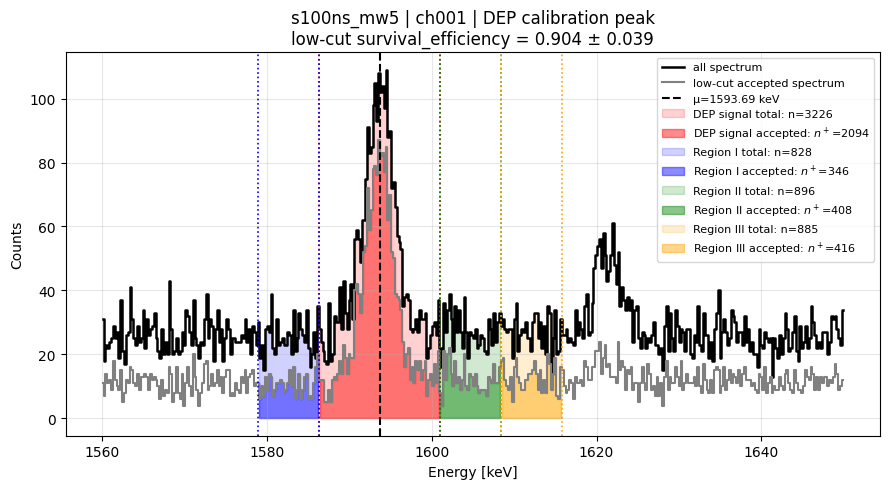

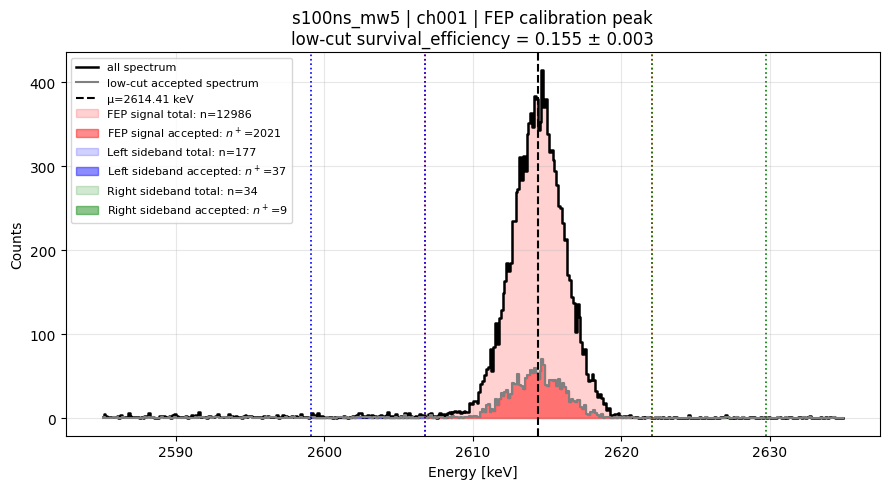

In [ ]:
run = 's100ns_mw5'

peak_db = find_cal_peaks_for_run(
    run_db=run_db,
    run=run,
    lh5=lh5,
    index=0,
    bins=400,
    energy_field=energy_field,
    low_cut_field=low_cut_field,
    dep_search_range=(1560, 1610),
    fep_search_range=(2585, 2635),
    do_plot=False,
    window_nsigma=4.5,
    plot_low_cut=True,
    # logstyle= True
)

In [ ]:
peak_db.keys()
peak_db['DEP']

{'mu': 1593.6861042609846,
 'sigma': 1.6362601745372163,
 'window': (1586.3229334755672, 1601.049275046402),
 'counts': {'dep': (2257.0, 3228.0),
  'I': (411.0, 825.0),
  'II': (490.0, 896.0),
  'III': (484.0, 885.0)},
 'survival': {'eps': 0.9024064171122995, 'sigma': 0.03553220679250788}}

In [ ]:
print("window_nsigma =", peak_db.get("window_nsigma", "not defined"))
print("DEP mu =", peak_db["DEP"]["mu"])
print("DEP sigma =", peak_db["DEP"]["sigma"])
print("DEP survival =", peak_db["DEP"]["survival"]["eps"], "+/-", peak_db["DEP"]["survival"]["sigma"])
print("FEP mu =", peak_db["FEP"]["mu"])
print("FEP sigma =", peak_db["FEP"]["sigma"])
print("FEP survival =", peak_db["FEP"]["survival"]["eps"], "+/-", peak_db["FEP"]["survival"]["sigma"])

window_nsigma = 4.5
DEP mu = 1593.688359789283
DEP sigma = 1.6365907885633804
DEP survival = 0.9040912139503688 +/- 0.038757659680739576
FEP mu = 2614.41039420875
FEP sigma = 1.7013375425481676
FEP survival = 0.15459882583170254 +/- 0.003268331216470394


raw DEP SF = 0.723202170963365
raw I SF   = 0.5105042016806722
raw II SF  = 0.4839357429718876
raw III SF = 0.5283842794759825
bkg total = 1014.0
bkg pass  = 483.0
signal total - bkg total = 1197.0
signal pass -bkg pass = 1116.0
dep total =  2211.0
dep pass =  1599.0
dep fail =  612.0


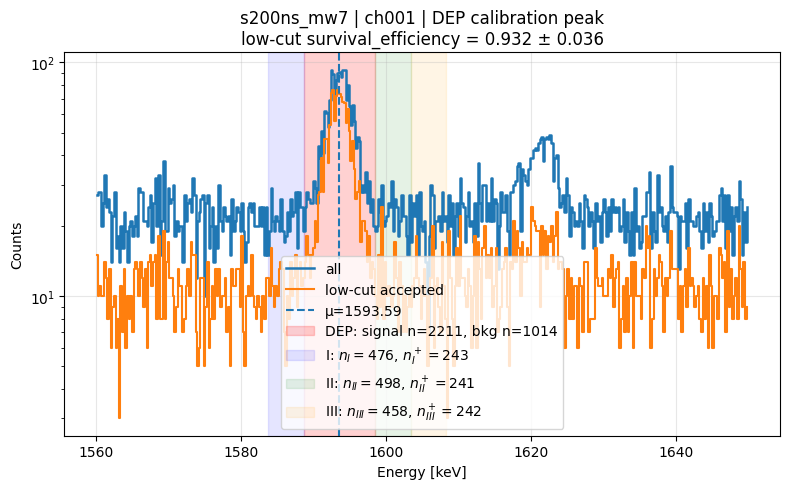

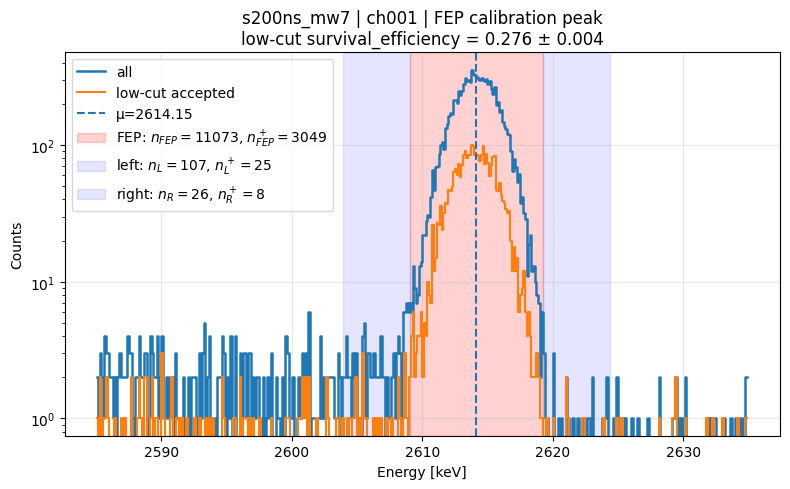

DEP mu = 1593.5922170504693
DEP sigma = 1.6377635556332224
DEP survival = 0.9323308270676691 +/- 0.0357361526059436
FEP mu = 2614.1474582555097
FEP sigma = 1.7048929307556735
FEP survival = 0.27568555758683727 +/- 0.004320749712948984
dep counts: = {'dep': (1599.0, 2211.0), 'I': (243.0, 476.0), 'II': (241.0, 498.0), 'III': (242.0, 458.0)}


In [ ]:
run = 's200ns_mw7'
peak_db = find_cal_peaks_for_run(
    run_db=run_db,
    run=run,
    lh5=lh5,
    index=0,
    bins=400,
    energy_field=energy_field,
    low_cut_field=low_cut_field,
    dep_search_range=(1560, 1610),
    fep_search_range=(2585, 2635),
    dep_fit_half_width=6.0,
    fep_fit_half_width=6.0,
    window_nsigma=3,
    do_plot=False,
    plot_low_cut=True,
    is_valid_waveform=True,
    logstyle = True
)

print("DEP mu =", peak_db["DEP"]["mu"])
print("DEP sigma =", peak_db["DEP"]["sigma"])
print("DEP survival =", peak_db["DEP"]["survival"]["eps"], "+/-", peak_db["DEP"]["survival"]["sigma"])
print("FEP mu =", peak_db["FEP"]["mu"])
print("FEP sigma =", peak_db["FEP"]["sigma"])
print("FEP survival =", peak_db["FEP"]["survival"]["eps"], "+/-", peak_db["FEP"]["survival"]["sigma"])
print("dep counts: =",peak_db["DEP"]['counts'])

In [ ]:
print(type(peak_db["DEP"]["survival"]))
print(peak_db["DEP"]["survival"].keys())

In [ ]:
peak_db = find_cal_peaks_for_run(run_db,
    run,
    lh5,
    bins=200,
    low_cut_field=low_cut_field,
    energy_field=energy_field,
    plot_low_cut=True,
    window_nsigma=1.5,    
)

In [ ]:
print("window_nsigma =", peak_db.get("window_nsigma", "not defined"))

## 构建单个 run 的 event db

这里不会先做 histogram，而是先保存：
- `aoe`
- `low_cut_true`
- `n_total`
- `n_low_cut_true`
- fraction


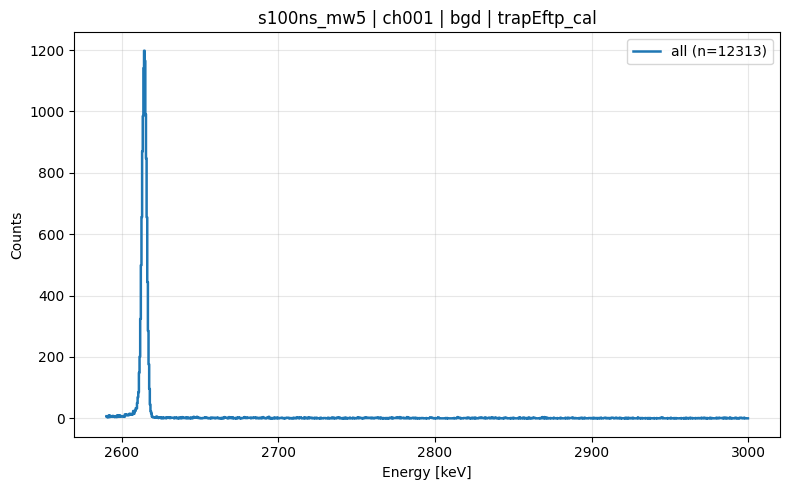

{'run': 's100ns_mw5',
 'channel': 'ch001',
 'energy_field': 'trapEftp_cal',
 'low_cut_field': None,
 'bins': 1000,
 'energy_range': (2590, 3000),
 'counts': array([7, 5, 3, ..., 0, 0, 0], shape=(1000,)),
 'edges': array([2590.  , 2590.41, 2590.82, ..., 2999.18, 2999.59, 3000.  ],
       shape=(1001,)),
 'centers': array([2590.205, 2590.615, 2591.025, ..., 2998.975, 2999.385, 2999.795],
       shape=(1000,))}

In [ ]:
plot_trapeftp(
    run_db=run_db,
    run="s100ns_mw5",
    lh5=lh5,
    index=0,
    dataset='bgd',
    energy_field="trapEftp_cal",
    bins=1000,
    energy_range=(2590, 3000),
    log_style=False
)

In [ ]:
event_db = build_lowcut_event_db_for_run(
    run_db=run_db,
    window=info['interval'],
    mw=info['mw_label'],
    lh5=lh5,
    index=index,
    aoe_field=aoe_field,
    low_cut_field=low_cut_field,
    energy_field=energy_field,
    use_fitted_peaks=True,
    do_peak_plot=False,
)

raw DEP SF = 0.5489210759680757
raw I SF   = 0.2974947807933194
raw II SF  = 0.3085427135678392
raw III SF = 0.33368532206969376
bkg total = 2001.0
bkg pass  = 583.0
signal total - bkg total = 1382.0
signal pass -bkg pass = 1274.0
dep total =  3383.0
dep pass =  1857.0
dep fail =  1526.0


## 先保存成 pkl，再画图

In [19]:
# single_pkl_name = f"{event_db['meta']['run']}_{event_db['meta']['channel']}_lowcut_event_fix_db.pkl"
single_pkl_name = 's100ns_mw5_ch002_lowcut_event_db.pkl'
# save_pkl(event_db, single_pkl_name)
# load_pkl("s100ns_mw5_ch002_lowcut_event_db.pkl")
# single_pkl_name = "s100ns_mw5_ch002_lowcut_event_db.pkl"

loaded from s100ns_mw5_ch002_lowcut_event_db.pkl


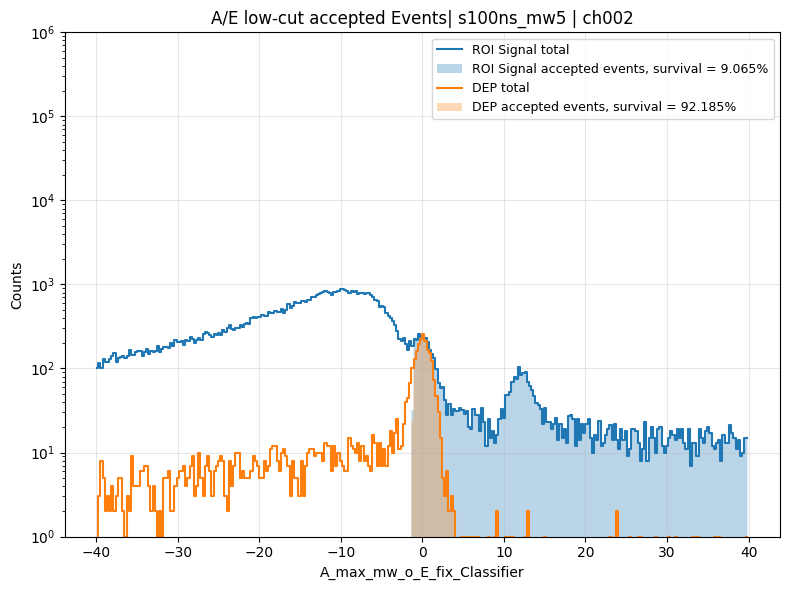

In [20]:
event_db_loaded = load_pkl(single_pkl_name)
hist_db = plot_lowcut_hist_from_event_db(
    event_db_loaded,
    bins=300,
    value_range=(-40, 40),
    show_labels=("ROI_Signal",'DEP'),
    ylim_top=1e6,
)


In [22]:
event_db_loaded["meta"].keys()

dict_keys(['run', 'channel', 'aoe_field', 'low_cut_field', 'energy_field', 'windows', 'peak_db', 'use_fitted_peaks', 'window_nsigma', 'survival_fep', 'survival_dep', 'survival_compton_signal', 'survival_compton_bg_subtracted'])

In [ ]:
def inspect_dict(d, name="event_db", level=0, max_level=3):
    indent = "  " * level
    if isinstance(d, dict):
        print(f"{indent}{name}: dict keys = {list(d.keys())}")
        if level < max_level:
            for k, v in d.items():
                inspect_dict(v, str(k), level + 1, max_level)
    else:
        try:
            print(f"{indent}{name}: {type(d)}, len={len(d)}")
        except TypeError:
            print(f"{indent}{name}: {type(d)}")

inspect_dict(event_db, max_level=2)

## 从 pkl 重新加载并画图

这一步用来验证：后面改图时不需要重新读 lh5。


In [ ]:
event_db_reload = load_pkl(single_pkl_name)

hist_db_reload = plot_lowcut_hist_from_event_db(
    event_db_reload,
    bins=500,
    value_range=(0.75, 1.25),
    ylim_top=1e6,
)


## 直接取某个样本的 pass / fail 数据

In [ ]:
print(event_db['events'].keys())

In [ ]:
dep_aoe = event_db['events']['ROI_BG']['aoe']
dep_pass = event_db['events']['ROI_BG']['low_cut_true']

dep_aoe_pass = dep_aoe[dep_pass]
dep_aoe_fail = dep_aoe[~dep_pass]

print('PHY_BG total :', len(dep_aoe))
print('PHY_BG pass  :', len(dep_aoe_pass))
print('PHY_BG fail  :', len(dep_aoe_fail))


## 可选：一次构建所有 runs 的 event db

第一次建议先不要直接跑全部。确认单个 run 没问题之后再打开。


In [ ]:
all_event_db = build_all_lowcut_event_db(
    run_db=run_db,
    lh5=lh5,
    indices=(1,),
    aoe_field=aoe_field,
    low_cut_field=low_cut_field,
    energy_field=energy_field,
    use_fitted_peaks=True,
)

save_pkl(all_event_db, 'all_lowcut_event_classifier_db.pkl')

all_summary = summarize_all_lowcut_event_db(all_event_db)
all_summary


[OK] s100ns_mw1 | ch002
[OK] s100ns_mw3 | ch002
[OK] s100ns_mw5 | ch002
[OK] s100ns_mw7 | ch002
[OK] s200ns_mw1 | ch002
[OK] s200ns_mw3 | ch002
[OK] s200ns_mw5 | ch002
[OK] s200ns_mw7 | ch002
[OK] s60ns_mw1 | ch002
[OK] s60ns_mw3 | ch002
[OK] s60ns_mw5 | ch002
[OK] s60ns_mw7 | ch002
saved to all_lowcut_event_classifier_db.pkl


{'s100ns_mw1': {'ch002': {'status': 'ok',
   'DEP_n_total': 3383,
   'DEP_n_true': 1949,
   'DEP_fraction_true': 0.5761158734850724,
   'FEP_n_total': 35813,
   'FEP_n_true': 3790,
   'FEP_fraction_true': 0.10582749280987351,
   'ROI_BG_n_total': 9343,
   'ROI_BG_n_true': 3117,
   'ROI_BG_fraction_true': 0.33361875200685004,
   'ROI_Signal_n_total': 76639,
   'ROI_Signal_n_true': 10706,
   'ROI_Signal_fraction_true': 0.13969388953404924}},
 's100ns_mw3': {'ch002': {'status': 'ok',
   'DEP_n_total': 3383,
   'DEP_n_true': 1838,
   'DEP_fraction_true': 0.5433047590895654,
   'FEP_n_total': 35813,
   'FEP_n_true': 2676,
   'FEP_fraction_true': 0.07472146985731438,
   'ROI_BG_n_total': 9343,
   'ROI_BG_n_true': 2561,
   'ROI_BG_fraction_true': 0.274108958578615,
   'ROI_Signal_n_total': 76639,
   'ROI_Signal_n_true': 7139,
   'ROI_Signal_fraction_true': 0.09315100666762353}},
 's100ns_mw5': {'ch002': {'status': 'ok',
   'DEP_n_total': 3383,
   'DEP_n_true': 1857,
   'DEP_fraction_true': 0.

In [ ]:
# save_pkl(all_event_db, 'all_lowcut_event_fix_db_r57r59.pkl')


NameError: name 'all_event_db' is not defined

## 常见后续用法

- 改 bins：只重新调用 `plot_lowcut_hist_from_event_db(...)`
- 改 A/E range：只改 `value_range`
- 单独画 pass / fail：直接用 `event_db['events'][label]['aoe']` 和 boolean mask
- 以后算 survival fraction：直接从 pkl 里的 event-level 数据继续算


In [5]:
all_summary = load_pkl("/mnt/atlas02/users/leoli/AoverE_analysis/low_cuts/all_lowcut_event_classifier_db_r57r59.pkl")

loaded from /mnt/atlas02/users/leoli/AoverE_analysis/low_cuts/all_lowcut_event_classifier_db_r57r59.pkl


In [39]:

save_pkl(all_summary, 'all_lowcut_event_fix_db_r57r59.pkl')

saved to all_lowcut_event_fix_db_r57r59.pkl


In [37]:
all_summary['s100ns_mw1']['ch002']['event_db']["meta"].keys()

dict_keys(['run', 'channel', 'aoe_field', 'low_cut_field', 'energy_field', 'windows', 'peak_db', 'use_fitted_peaks', 'window_nsigma', 'survival_fep', 'survival_dep', 'survival_compton_signal', 'survival_compton_bg_subtracted'])

In [6]:
for run, run_dict in all_summary.items():
    print(f"\n=== {run} ===")
    for channel, res in run_dict.items():
        print(f"  -- {channel} --")
        print(f"     status: {res.get('status')}")
        if res.get("status") == "ok":
            event_db = res["event_db"]
            for label, info in event_db["events"].items():
                print(
                    f"    {label}: "
                    f"n_total={info['n_total']}, "
                    f"n_low_cut_true={info['n_low_cut_true']}, "
                    f"fraction={info['fraction_low_cut_true']:.4f}"
                )
        else:
            print(f"     error: {res.get('error')}")


=== s100ns_mw1 ===
  -- ch002 --
     status: ok
    DEP: n_total=3383, n_low_cut_true=1949, fraction=0.5761
    FEP: n_total=35813, n_low_cut_true=3790, fraction=0.1058
    ROI_BG: n_total=9343, n_low_cut_true=3117, fraction=0.3336
    ROI_Signal: n_total=76639, n_low_cut_true=10706, fraction=0.1397

=== s100ns_mw3 ===
  -- ch002 --
     status: ok
    DEP: n_total=3383, n_low_cut_true=1838, fraction=0.5433
    FEP: n_total=35813, n_low_cut_true=2676, fraction=0.0747
    ROI_BG: n_total=9343, n_low_cut_true=2561, fraction=0.2741
    ROI_Signal: n_total=76639, n_low_cut_true=7139, fraction=0.0932

=== s100ns_mw5 ===
  -- ch002 --
     status: ok
    DEP: n_total=3383, n_low_cut_true=1857, fraction=0.5489
    FEP: n_total=35813, n_low_cut_true=2893, fraction=0.0808
    ROI_BG: n_total=9343, n_low_cut_true=2408, fraction=0.2577
    ROI_Signal: n_total=76639, n_low_cut_true=6947, fraction=0.0906

=== s100ns_mw7 ===
  -- ch002 --
     status: ok
    DEP: n_total=3383, n_low_cut_true=1847,

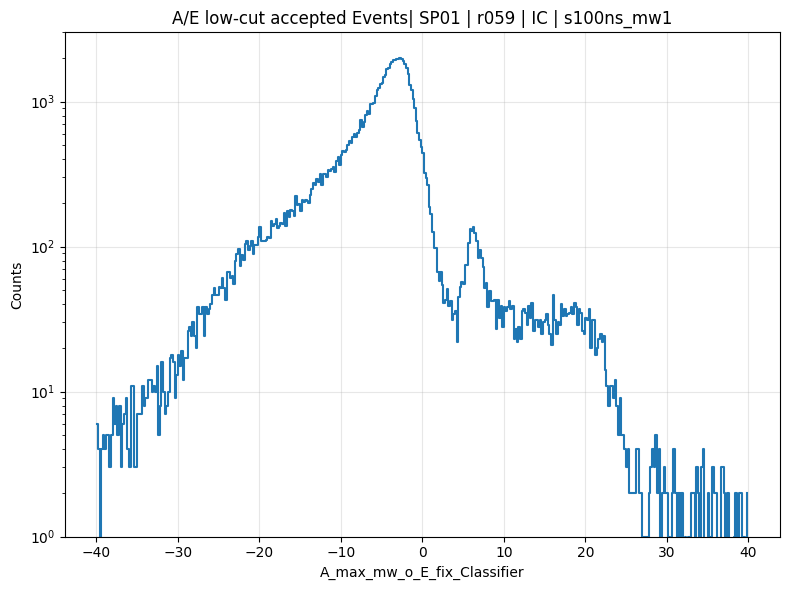

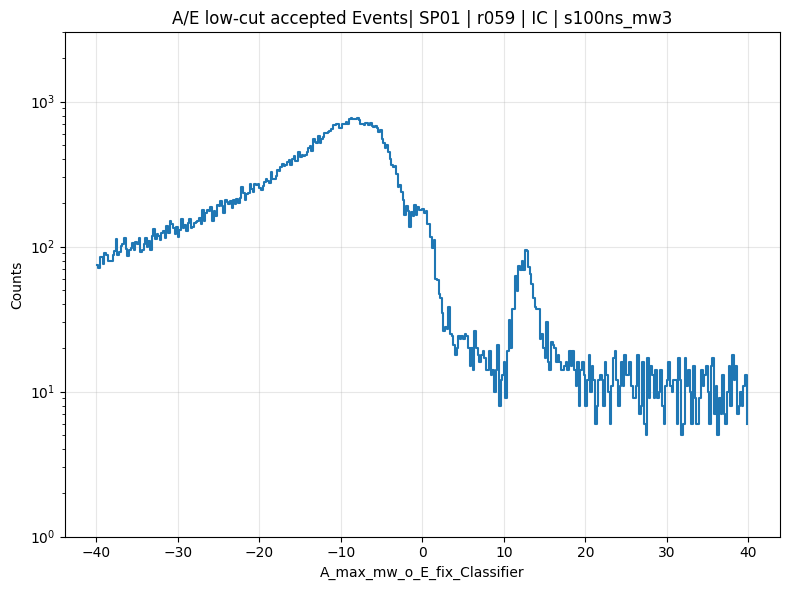

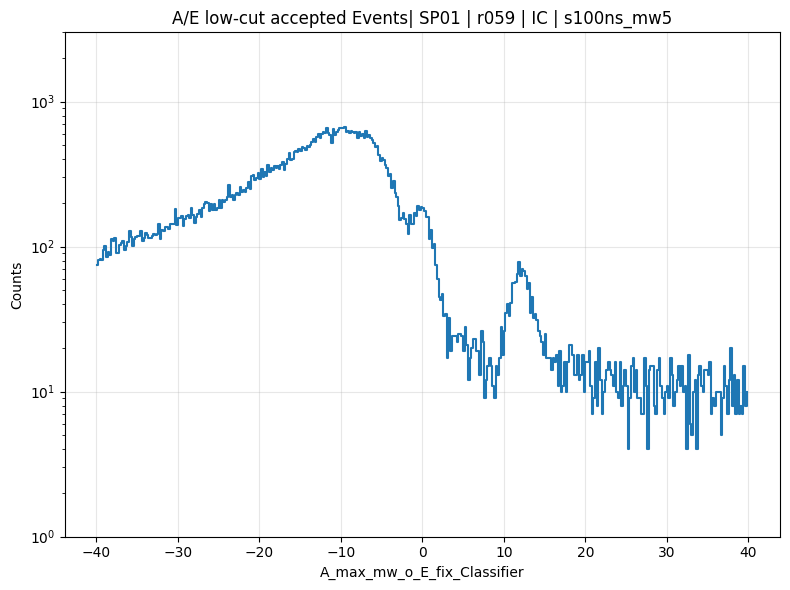

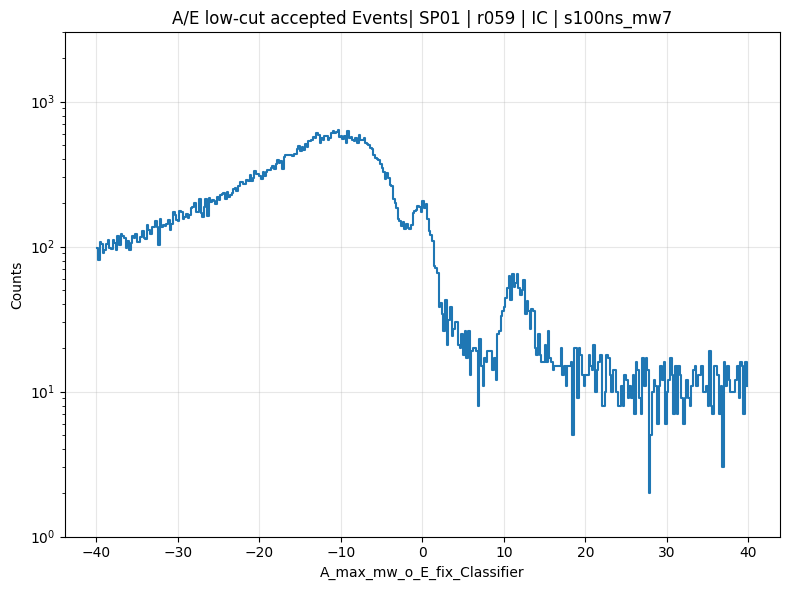

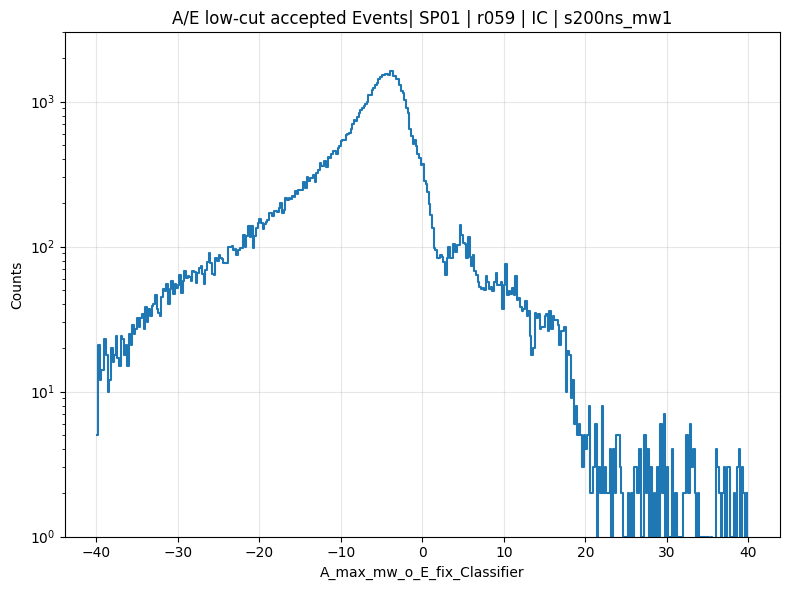

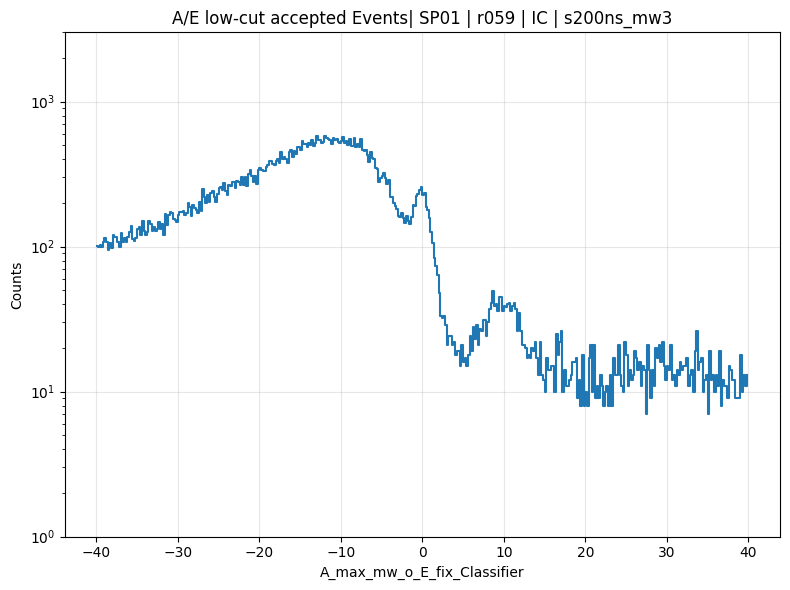

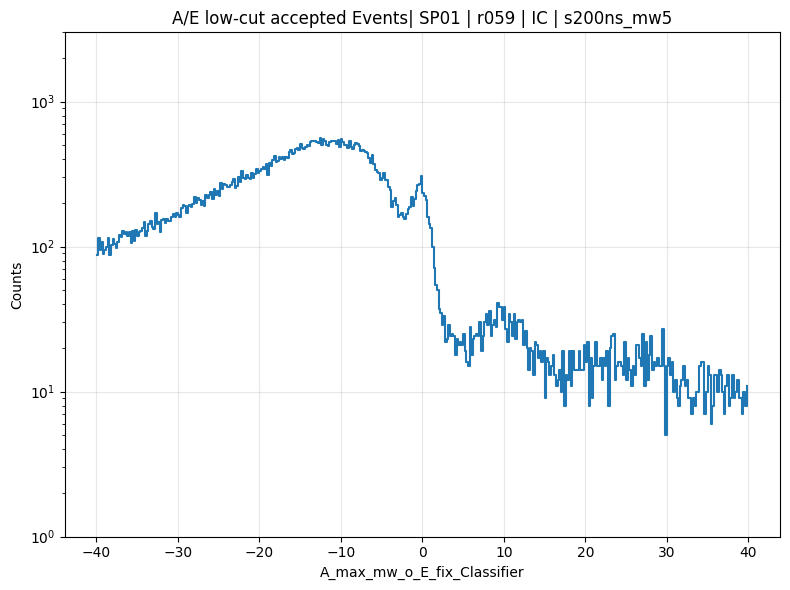

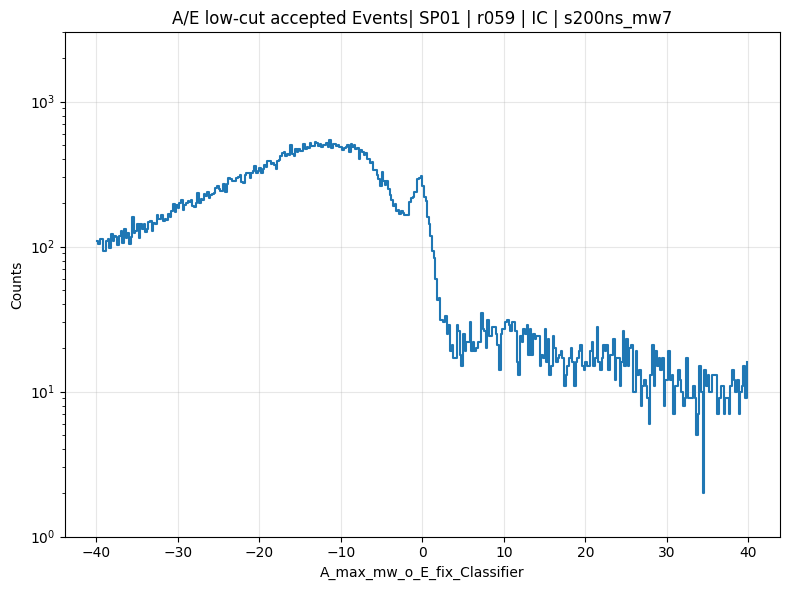

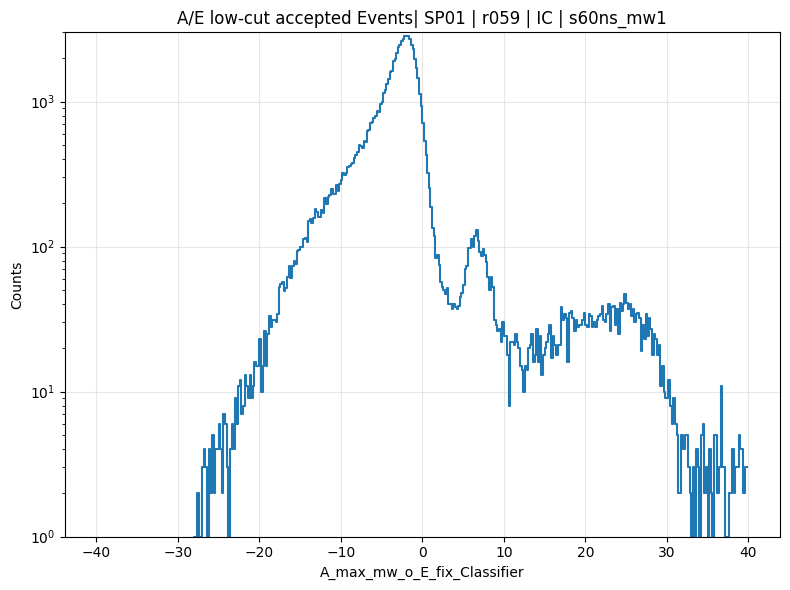

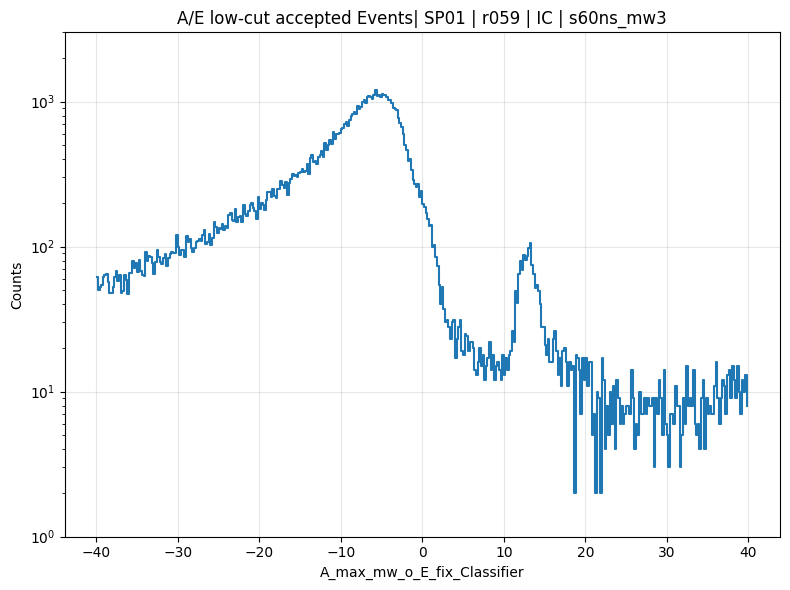

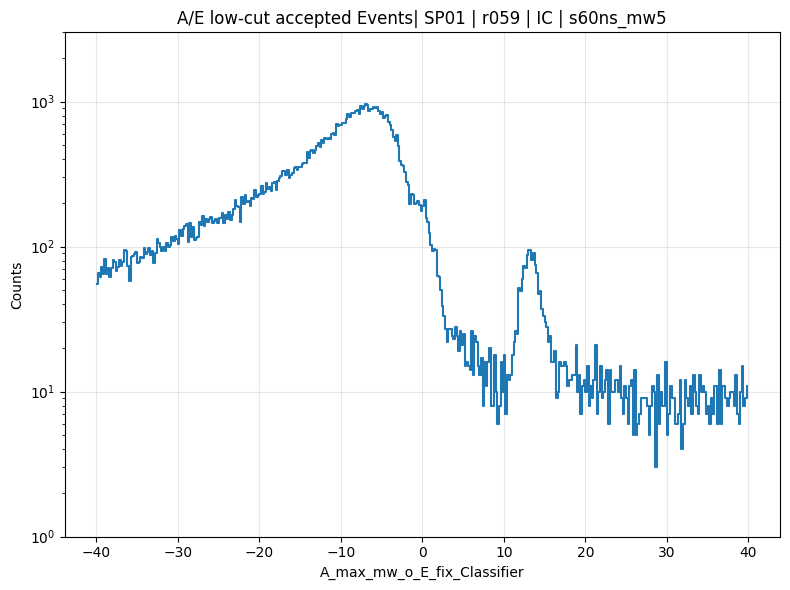

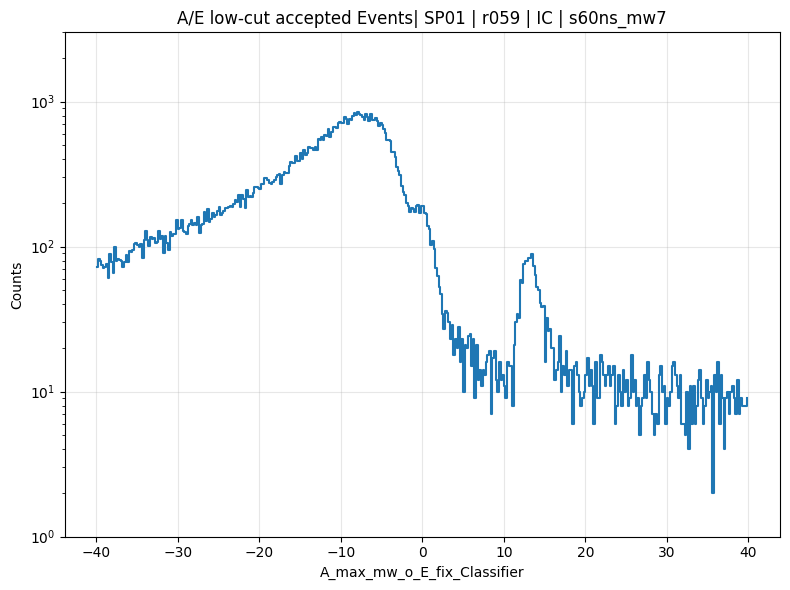

In [14]:
for run, run_dict in all_summary.items():
    for channel, res in run_dict.items():
        if res.get("status") != "ok":
            print(f"skip {run} {channel}: {res.get('error')}")
            continue
        event_db = res["event_db"]
        hist_db = plot_lowcut_hist_from_event_db(
            event_db,
            bins=400,
            value_range=(-40, 40),
            show_labels=("ROI_Signal",),
            ylim_top=3e3
        )

In [ ]:
import os
import matplotlib.pyplot as plt

save_dir = "./lowcut_plots/A_max_mw_o_E_Corrected"
os.makedirs(save_dir, exist_ok=True)

for run, run_dict in all_summary.items():
    for channel, res in run_dict.items():
        if res.get("status") != "ok":
            print(f"skip {run} {channel}: {res.get('error')}")
            continue
        save_fig = os.path.join(save_dir, f"{run}_{channel}_A_max_mw_o_E_Corrected.png")
        event_db = res["event_db"]

        hist_db = plot_lowcut_hist_from_event_db(
            event_db,
            bins=400,
            value_range=(0.75, 1.25),
            show_labels=("DEP", "ROI_Signal"),
            save_fig=save_fig,
            plot=False
        )

In [ ]:

def compare_lowcut_field_across_runs(
    run_db,
    runs,
    lh5,
    dataset="phy_signal",
    channel="ch002",
    table="hit",
    low_cut_field="A_max_mw_o_E_Low_Cut",
    is_valid_waveform=False,
    reference_run=None,
    max_print=10,
):
    """
    Compare stored low-cut boolean field across runs.

    This checks:
      - length
      - n_true / n_false
      - true fraction
      - exact equality to a reference run, only meaningful if same length/event order

    Parameters
    ----------
    run_db : dict
        Your run database.
    runs : list
        List of run labels, e.g. ["s60ns_mw1", "s100ns_mw3"].
    lh5 : LH5Store
        pygama/legend lh5 store.
    dataset : str
        "cal", "phy_bg", or "phy_signal".
    channel : str
        e.g. "ch001" or "ch002".
    table : str
        Usually "hit".
    low_cut_field : str
        Boolean low-cut field name.
    is_valid_waveform : bool
        Passed to your read_array_from_run helper.
    reference_run : str or None
        If None, first run is used as reference.
    """

    if reference_run is None:
        reference_run = runs[0]

    rows = []
    arrays = {}

    for run in runs:
        try:
            low = read_array_from_run(
                run_db,
                run,
                lh5,
                dataset=dataset,
                channel=channel,
                table=table,
                field=low_cut_field,
                is_valid_waveform=is_valid_waveform,
            )

            low = np.asarray(low).astype(bool)

            n_total = low.size
            n_true = int(np.count_nonzero(low))
            n_false = int(n_total - n_true)
            frac_true = n_true / n_total if n_total > 0 else np.nan

            arrays[run] = low

            rows.append({
                "run": run,
                "status": "ok",
                "dataset": dataset,
                "channel": channel,
                "field": low_cut_field,
                "n_total": n_total,
                "n_true": n_true,
                "n_false": n_false,
                "frac_true": frac_true,
                "frac_false": 1 - frac_true if np.isfinite(frac_true) else np.nan,
            })

        except Exception as e:
            rows.append({
                "run": run,
                "status": "error",
                "dataset": dataset,
                "channel": channel,
                "field": low_cut_field,
                "n_total": np.nan,
                "n_true": np.nan,
                "n_false": np.nan,
                "frac_true": np.nan,
                "frac_false": np.nan,
                "error": repr(e),
            })

    df = pd.DataFrame(rows)

    # Compare to reference run if possible
    ref = arrays.get(reference_run, None)

    equal_to_ref = []
    diff_count_to_ref = []
    same_length_as_ref = []

    for run in df["run"]:
        arr = arrays.get(run, None)

        if ref is None or arr is None:
            equal_to_ref.append(np.nan)
            diff_count_to_ref.append(np.nan)
            same_length_as_ref.append(np.nan)
            continue

        same_len = len(arr) == len(ref)
        same_length_as_ref.append(same_len)

        if same_len:
            diff_count = int(np.count_nonzero(arr != ref))
            diff_count_to_ref.append(diff_count)
            equal_to_ref.append(diff_count == 0)
        else:
            diff_count_to_ref.append(np.nan)
            equal_to_ref.append(False)

    df["reference_run"] = reference_run
    df["same_length_as_ref"] = same_length_as_ref
    df["equal_to_ref"] = equal_to_ref
    df["diff_count_to_ref"] = diff_count_to_ref

    # Print compact summary
    print(f"Compare low-cut field: {low_cut_field}")
    print(f"dataset={dataset}, channel={channel}, reference={reference_run}")
    print(df.head(max_print))

    gc.collect()
    return df, arrays

In [ ]:
df_lowcut, lowcut_arrays = compare_lowcut_field_across_runs(
    run_db=run_db,
    runs=runs,
    lh5=lh5,
    dataset="phy_signal",
    channel="ch002",
    table="hit",
    low_cut_field="A_max_mw_o_E_Low_Cut",
)

In [ ]:
df_lowcut[["run", "n_total", "n_true", "frac_true", "equal_to_ref", "diff_count_to_ref"]]

In [ ]:
df_lowcut_cal, _ = compare_lowcut_field_across_runs(
    run_db=run_db,
    runs=runs,
    lh5=lh5,
    dataset="cal",
    channel="ch002",
    low_cut_field="A_max_mw_o_E_Low_Cut",
)